# ExtraSensoryPhone Single-Pair Processing Inspection

这个 notebook 用来在单个 ExtraSensoryPhone acc/gyro 文件对上验证处理流程，暂不写入正式 `/Volumes/Felix_Backups/Processed2`。

检查重点：

- 读取 `raw_acc/{uuid}/{timestamp}.m_raw_acc.dat`
- 读取 `proc_gyro/{uuid}/{timestamp}.m_proc_gyro.dat`
- 按 acc 模长中位数判断单位并统一到 `m/s^2`
- gyro 按 `rad/s` 保持不变
- 取 acc/gyro 时间交集
- 检查每秒 raw frame count
- 一阶线性插值到 `40 Hz`
- 生成 `10s`、`512f`、`1024f` 三种样例片段
- `1024f` 不足 1024 帧时尾部补 0，并在 manifest label 中记录 `pad_frames`

默认样例是：

```text
0A986513-7828-4D53-AA1F-E02D6DF9561B/1449601597
```

## 0. Imports And Config

`OUTPUT_ROOT` 只用于 notebook 调试输出，不是正式 processed 目录。

In [1]:
from pathlib import Path
import json
import math
from collections import Counter
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

RAW_ROOT = Path('/Volumes/Felix_Backups/ExtraSensoryPhone')
OUTPUT_ROOT = Path('/Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs')
SOURCE = 'ExtraSensoryPhone'
DEVICE = 'phone'

TARGET_FREQ = 40.0
TARGET_DT_MS = 1000.0 / TARGET_FREQ
ACC_MIN_RAW_HZ = 30
GYRO_MIN_RAW_HZ = 35
G_TO_MPS2 = 9.80665

SAMPLE_UUID = '0A986513-7828-4D53-AA1F-E02D6DF9561B'
SAMPLE_TIMESTAMP = '1449601597'

MODE_SPECS = {
    '10s': {'frames': 400, 'duration_sec': 10.0, 'padding': False},
    '512f': {'frames': 512, 'duration_sec': 512 / TARGET_FREQ, 'padding': False},
    '1024f': {'frames': 1024, 'duration_sec': 1024 / TARGET_FREQ, 'padding': True, 'min_real_frames': 512},
}

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['savefig.bbox'] = 'tight'

print('RAW_ROOT exists:', RAW_ROOT.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('TARGET_FREQ:', TARGET_FREQ, 'Hz')
print('TARGET_DT_MS:', TARGET_DT_MS, 'ms')
print('ACC_MIN_RAW_HZ:', ACC_MIN_RAW_HZ)
print('GYRO_MIN_RAW_HZ:', GYRO_MIN_RAW_HZ)

RAW_ROOT exists: True
OUTPUT_ROOT: /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs
TARGET_FREQ: 40.0 Hz
TARGET_DT_MS: 25.0 ms
ACC_MIN_RAW_HZ: 30
GYRO_MIN_RAW_HZ: 35


## 1. Discover Files And Pick One Pair

只处理 acc 和 gyro 都存在的 `{uuid}/{timestamp}` 文件对。

In [2]:
def paired_key_from_acc(path: Path) -> str:
    return path.relative_to(RAW_ROOT / 'raw_acc').as_posix().replace('.m_raw_acc.dat', '')


def paired_key_from_gyro(path: Path) -> str:
    return path.relative_to(RAW_ROOT / 'proc_gyro').as_posix().replace('.m_proc_gyro.dat', '')


acc_files = {paired_key_from_acc(path): path for path in (RAW_ROOT / 'raw_acc').glob('*/*.m_raw_acc.dat')}
gyro_files = {paired_key_from_gyro(path): path for path in (RAW_ROOT / 'proc_gyro').glob('*/*.m_proc_gyro.dat')}
paired_keys = sorted(set(acc_files) & set(gyro_files))

print('acc files:', len(acc_files))
print('gyro files:', len(gyro_files))
print('paired files:', len(paired_keys))
print('acc-only files:', len(set(acc_files) - set(gyro_files)))
print('paired users:', len({key.split('/')[0] for key in paired_keys}))

sample_key = f'{SAMPLE_UUID}/{SAMPLE_TIMESTAMP}'
if sample_key not in paired_keys:
    raise FileNotFoundError(f'missing paired sample: {sample_key}')

acc_path = acc_files[sample_key]
gyro_path = gyro_files[sample_key]
print('sample acc:', acc_path)
print('sample gyro:', gyro_path)

acc files: 377056
gyro files: 359912
paired files: 359912
acc-only files: 17144
paired users: 57
sample acc: /Volumes/Felix_Backups/ExtraSensoryPhone/raw_acc/0A986513-7828-4D53-AA1F-E02D6DF9561B/1449601597.m_raw_acc.dat
sample gyro: /Volumes/Felix_Backups/ExtraSensoryPhone/proc_gyro/0A986513-7828-4D53-AA1F-E02D6DF9561B/1449601597.m_proc_gyro.dat


## 2. Read And Clean One Signal

每个 `.dat` 是 4 列：`time, x, y, z`。这里会丢弃非有限行、按时间排序、重复时间戳保留第一条。

In [3]:
def read_dat(path: Path) -> tuple[np.ndarray, np.ndarray, dict]:
    """Read one ExtraSensoryPhone .dat file as time and xyz arrays."""

    data = np.loadtxt(path, dtype=np.float64)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    if data.shape[1] != 4:
        raise ValueError(f'unexpected column count {data.shape[1]}: {path}')

    finite = np.all(np.isfinite(data), axis=1)
    dropped_nonfinite = int(np.sum(~finite))
    data = data[finite]
    if len(data) < 2:
        raise ValueError(f'too few finite rows: {path}')

    original_t = data[:, 0]
    original_dt = np.diff(original_t)
    nonpositive_dt_original_order = int(np.sum(original_dt <= 0))

    order = np.argsort(original_t, kind='stable')
    data = data[order]
    sorted_t = data[:, 0]
    sorted_xyz = data[:, 1:4]

    unique_t, first_idx = np.unique(sorted_t, return_index=True)
    xyz = sorted_xyz[first_idx]
    duplicate_timestamps = int(len(sorted_t) - len(unique_t))

    stats = {
        'rows': int(len(original_t)),
        'clean_rows': int(len(unique_t)),
        'dropped_nonfinite': dropped_nonfinite,
        'duplicate_timestamps': duplicate_timestamps,
        'nonpositive_dt_original_order': nonpositive_dt_original_order,
    }
    return unique_t, xyz, stats


def signal_summary(time_s: np.ndarray, xyz: np.ndarray) -> dict:
    """Summarize a signal timeline and magnitude."""

    dt = np.diff(time_s)
    pos_dt = dt[dt > 0]
    mag = np.linalg.norm(xyz, axis=1)
    return {
        'rows': int(len(time_s)),
        'duration_sec': float(time_s[-1] - time_s[0]),
        'avg_hz': float((len(time_s) - 1) / (time_s[-1] - time_s[0])),
        'median_dt_sec': float(np.median(pos_dt)),
        'min_dt_sec': float(np.min(pos_dt)),
        'p95_dt_sec': float(np.percentile(pos_dt, 95)),
        'max_dt_sec': float(np.max(pos_dt)),
        'mag_median': float(np.median(mag)),
        'mag_min': float(np.min(mag)),
        'mag_max': float(np.max(mag)),
    }


acc_t, acc_xyz_raw, acc_read_stats = read_dat(acc_path)
gyro_t, gyro_xyz, gyro_read_stats = read_dat(gyro_path)

print('acc read stats:', json.dumps(acc_read_stats, indent=2))
print('gyro read stats:', json.dumps(gyro_read_stats, indent=2))
print('acc summary:', json.dumps(signal_summary(acc_t, acc_xyz_raw), indent=2))
print('gyro summary:', json.dumps(signal_summary(gyro_t, gyro_xyz), indent=2))

acc read stats: {
  "rows": 800,
  "clean_rows": 800,
  "dropped_nonfinite": 0,
  "duplicate_timestamps": 0,
  "nonpositive_dt_original_order": 0
}
gyro read stats: {
  "rows": 800,
  "clean_rows": 800,
  "dropped_nonfinite": 0,
  "duplicate_timestamps": 0,
  "nonpositive_dt_original_order": 0
}
acc summary: {
  "rows": 800,
  "duration_sec": 23.21229999989737,
  "avg_hz": 34.42140589271777,
  "median_dt_sec": 0.029540999967139214,
  "min_dt_sec": 0.025572999904397875,
  "p95_dt_sec": 0.029541000025346875,
  "max_dt_sec": 0.0767819999018684,
  "mag_median": 1.0007386010782304,
  "mag_min": 0.8547181069219658,
  "mag_max": 1.0490515856472324
}
gyro summary: {
  "rows": 800,
  "duration_sec": 19.989793958317023,
  "avg_hz": 39.97039697688156,
  "median_dt_sec": 0.025024000031407923,
  "min_dt_sec": 0.0249603750417009,
  "p95_dt_sec": 0.025025000039022416,
  "max_dt_sec": 0.025025000097230077,
  "mag_median": 0.0019782264877236952,
  "mag_min": 0.00032761267301934264,
  "mag_max": 0.05584

## 3. Infer Acc Unit

按文件 acc 模长中位数判断单位：

- `0.7 <= median <= 1.5`：视为 `g`，乘 `9.80665`
- `6.0 <= median <= 15.0`：视为 `m/s^2`，保持不变
- 其他范围：跳过或单独审查

In [4]:
def infer_acc_unit(acc_xyz: np.ndarray) -> tuple[str, float, float]:
    """Infer acceleration unit from median magnitude and return unit plus multiplier."""

    median_mag = float(np.median(np.linalg.norm(acc_xyz, axis=1)))
    if 0.7 <= median_mag <= 1.5:
        return 'g', G_TO_MPS2, median_mag
    if 6.0 <= median_mag <= 15.0:
        return 'm/s^2', 1.0, median_mag
    return 'unknown', float('nan'), median_mag


acc_unit, acc_multiplier, acc_median_mag = infer_acc_unit(acc_xyz_raw)
print('acc_unit:', acc_unit)
print('acc_median_magnitude:', acc_median_mag)
print('acc_multiplier:', acc_multiplier)
if acc_unit == 'unknown':
    raise ValueError('unknown acc unit; this file should be skipped in full processing')

acc_xyz = acc_xyz_raw * acc_multiplier
print('converted acc median magnitude m/s^2:', float(np.median(np.linalg.norm(acc_xyz, axis=1))))
print('gyro assumed unit: rad/s')

acc_unit: g
acc_median_magnitude: 1.0007386010782304
acc_multiplier: 9.80665
converted acc median magnitude m/s^2: 9.813893202263829
gyro assumed unit: rad/s


## 4. Overlap And Raw Quality Bins

只使用 acc 和 gyro 的时间交集。质量检查在这个重叠区内按 1 秒 bin 统计 raw frame count。

In [5]:
def overlap_signals(
    acc_t: np.ndarray,
    acc_xyz: np.ndarray,
    gyro_t: np.ndarray,
    gyro_xyz: np.ndarray,
) -> dict:
    """Trim acc and gyro to their shared time range and shift time to overlap start."""

    start = max(float(acc_t[0]), float(gyro_t[0]))
    end = min(float(acc_t[-1]), float(gyro_t[-1]))
    if end <= start:
        raise ValueError('no acc/gyro overlap')

    acc_mask = (acc_t >= start) & (acc_t <= end)
    gyro_mask = (gyro_t >= start) & (gyro_t <= end)
    return {
        'start_abs_s': start,
        'end_abs_s': end,
        'duration_sec': end - start,
        'acc_t_s': acc_t[acc_mask] - start,
        'acc_xyz': acc_xyz[acc_mask],
        'gyro_t_s': gyro_t[gyro_mask] - start,
        'gyro_xyz': gyro_xyz[gyro_mask],
    }


def build_quality_bins(time_s: np.ndarray, min_hz: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Count raw samples in 1-second bins and mark bins that meet min_hz."""

    end = math.ceil(float(time_s[-1]))
    bins = np.arange(0.0, end + 1.0, 1.0)
    counts, _ = np.histogram(time_s, bins=bins)
    valid = counts >= min_hz
    return bins, counts, valid


overlap = overlap_signals(acc_t, acc_xyz, gyro_t, gyro_xyz)
acc_bins, acc_counts, acc_valid = build_quality_bins(overlap['acc_t_s'], ACC_MIN_RAW_HZ)
gyro_bins, gyro_counts, gyro_valid = build_quality_bins(overlap['gyro_t_s'], GYRO_MIN_RAW_HZ)

print('overlap duration sec:', overlap['duration_sec'])
print('acc overlap rows:', len(overlap['acc_t_s']))
print('gyro overlap rows:', len(overlap['gyro_t_s']))
print('acc valid seconds:', int(acc_valid.sum()), '/', len(acc_valid))
print('gyro valid seconds:', int(gyro_valid.sum()), '/', len(gyro_valid))
print('acc counts first 20:', acc_counts[:20].tolist())
print('gyro counts first 20:', gyro_counts[:20].tolist())

overlap duration sec: 19.989793958317023
acc overlap rows: 676
gyro overlap rows: 800
acc valid seconds: 20 / 20
gyro valid seconds: 20 / 20
acc counts first 20: [33, 34, 34, 34, 34, 34, 34, 33, 34, 34, 34, 34, 34, 34, 33, 34, 34, 34, 34, 33]
gyro counts first 20: [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40]


saved: /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs/figures/raw_quality.svg


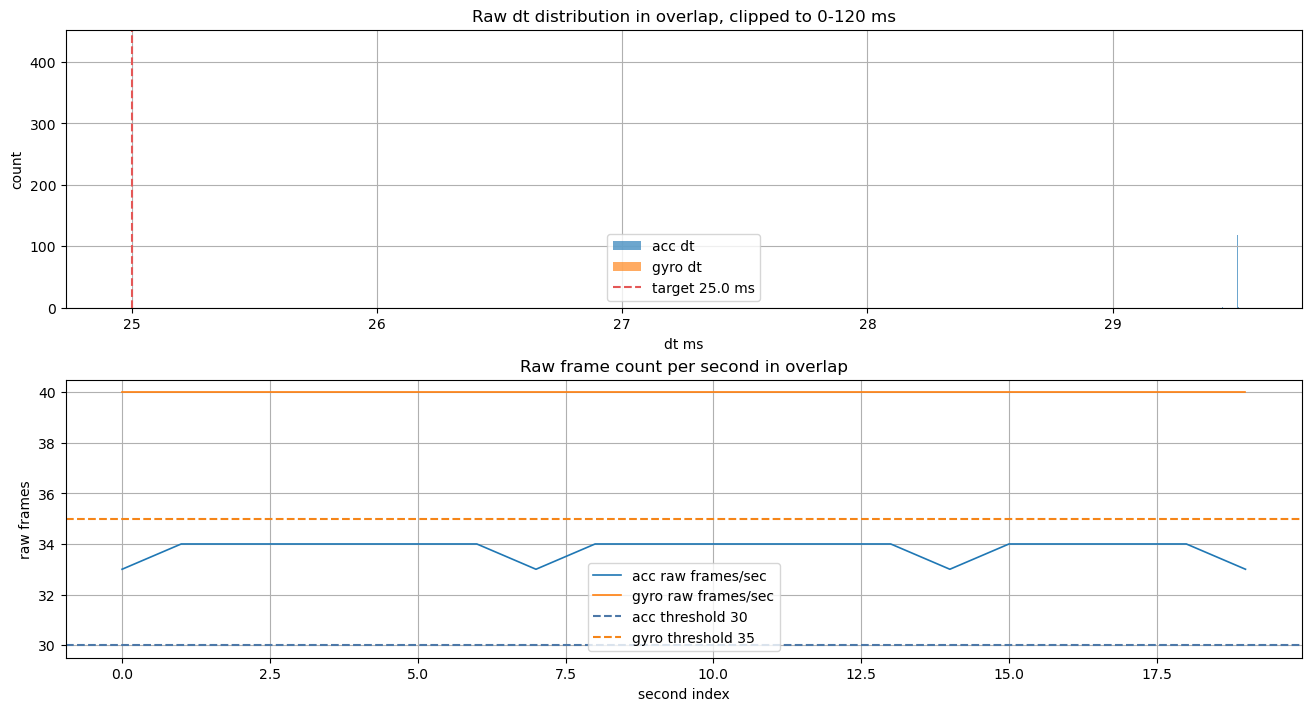

In [6]:
acc_dt_ms = np.diff(overlap['acc_t_s']) * 1000.0
gyro_dt_ms = np.diff(overlap['gyro_t_s']) * 1000.0
seconds = np.arange(max(len(acc_counts), len(gyro_counts)))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)
axes[0].hist(np.clip(acc_dt_ms, 0, 120), bins=80, alpha=0.65, label='acc dt')
axes[0].hist(np.clip(gyro_dt_ms, 0, 120), bins=80, alpha=0.65, label='gyro dt')
axes[0].axvline(TARGET_DT_MS, color='#E45756', linestyle='--', label=f'target {TARGET_DT_MS:.1f} ms')
axes[0].set_title('Raw dt distribution in overlap, clipped to 0-120 ms')
axes[0].set_xlabel('dt ms')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].plot(np.arange(len(acc_counts)), acc_counts, label='acc raw frames/sec', linewidth=1.2)
axes[1].plot(np.arange(len(gyro_counts)), gyro_counts, label='gyro raw frames/sec', linewidth=1.2)
axes[1].axhline(ACC_MIN_RAW_HZ, color='#4C78A8', linestyle='--', label='acc threshold 30')
axes[1].axhline(GYRO_MIN_RAW_HZ, color='#F58518', linestyle='--', label='gyro threshold 35')
axes[1].set_title('Raw frame count per second in overlap')
axes[1].set_xlabel('second index')
axes[1].set_ylabel('raw frames')
axes[1].legend()

fig_path = OUTPUT_ROOT / 'figures' / 'raw_quality.svg'
fig.savefig(fig_path)
print('saved:', fig_path)
plt.show()

## 5. Resample To 40 Hz

在重叠区内一阶线性插值到 `40 Hz`，不做 extrapolation。

In [7]:
def interpolate_columns(time_s: np.ndarray, xyz: np.ndarray, target_s: np.ndarray) -> np.ndarray:
    """Linearly interpolate each xyz column to target_s."""

    out = np.empty((len(target_s), xyz.shape[1]), dtype=np.float64)
    for axis in range(xyz.shape[1]):
        out[:, axis] = np.interp(target_s, time_s, xyz[:, axis])
    return out


def resample_overlap(overlap: dict) -> dict:
    """Resample acc and gyro overlap to TARGET_FREQ."""

    step_s = 1.0 / TARGET_FREQ
    target_s = np.arange(0.0, overlap['duration_sec'] + 1e-12, step_s, dtype=np.float64)
    target_s = target_s[target_s <= overlap['duration_sec']]
    return {
        'time_ms': target_s * 1000.0,
        'acc': interpolate_columns(overlap['acc_t_s'], overlap['acc_xyz'], target_s),
        'gyro': interpolate_columns(overlap['gyro_t_s'], overlap['gyro_xyz'], target_s),
    }


resampled = resample_overlap(overlap)
print('target frames:', len(resampled['time_ms']))
print('target duration sec:', float(resampled['time_ms'][-1] / 1000.0))
print('median target dt ms:', float(np.median(np.diff(resampled['time_ms']))))
print('resampled acc median magnitude:', float(np.median(np.linalg.norm(resampled['acc'], axis=1))))
print('resampled gyro median magnitude:', float(np.median(np.linalg.norm(resampled['gyro'], axis=1))))

target frames: 800
target duration sec: 19.975
median target dt ms: 25.0
resampled acc median magnitude: 9.807904634028597
resampled gyro median magnitude: 0.0016218339033085274


saved: /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs/figures/resampled_magnitude.svg


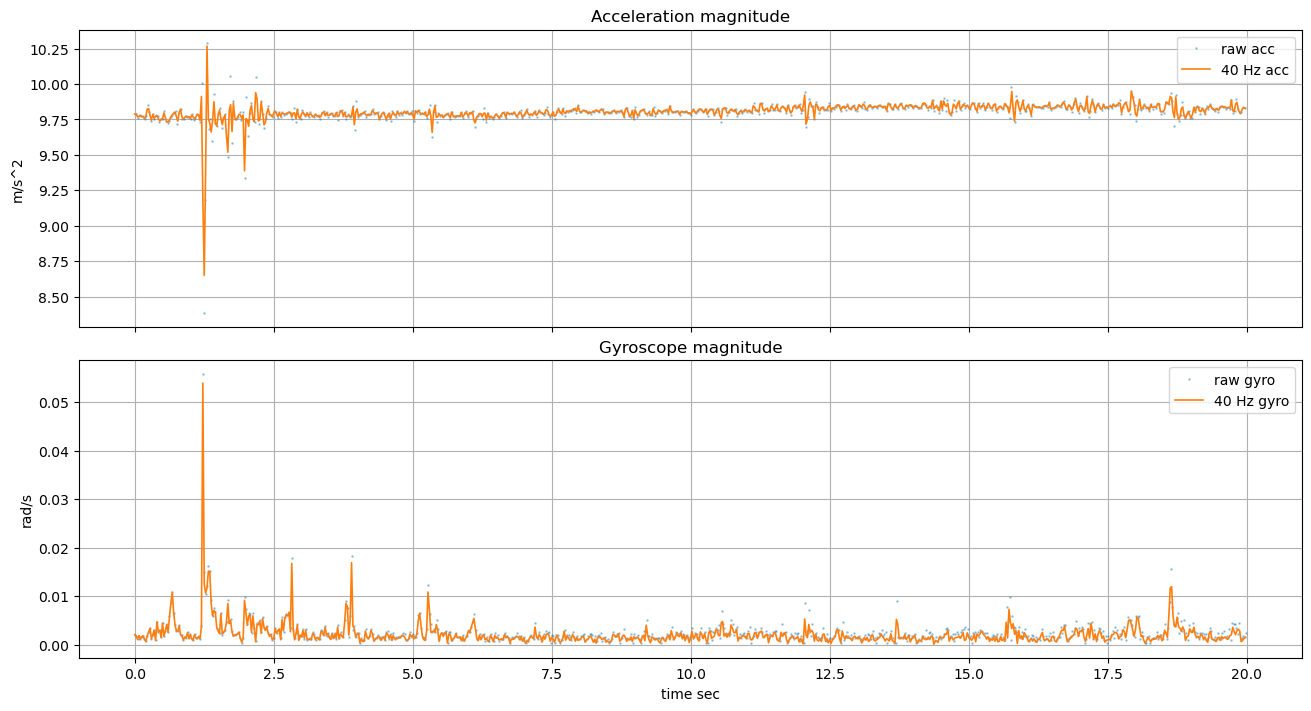

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
axes[0].plot(overlap['acc_t_s'], np.linalg.norm(overlap['acc_xyz'], axis=1), '.', markersize=1.8, alpha=0.35, label='raw acc')
axes[0].plot(resampled['time_ms'] / 1000.0, np.linalg.norm(resampled['acc'], axis=1), linewidth=1.2, label='40 Hz acc')
axes[0].set_title('Acceleration magnitude')
axes[0].set_ylabel('m/s^2')
axes[0].legend()

axes[1].plot(overlap['gyro_t_s'], np.linalg.norm(overlap['gyro_xyz'], axis=1), '.', markersize=1.8, alpha=0.35, label='raw gyro')
axes[1].plot(resampled['time_ms'] / 1000.0, np.linalg.norm(resampled['gyro'], axis=1), linewidth=1.2, label='40 Hz gyro')
axes[1].set_title('Gyroscope magnitude')
axes[1].set_xlabel('time sec')
axes[1].set_ylabel('rad/s')
axes[1].legend()

fig_path = OUTPUT_ROOT / 'figures' / 'resampled_magnitude.svg'
fig.savefig(fig_path)
print('saved:', fig_path)
plt.show()

## 6. Segment Selection

`10s` 和 `512f` 不 padding。`1024f` 允许尾部 padding，但真实有效帧数必须至少 `512`。

In [9]:
def target_quality_index(target_ms: np.ndarray, bins_s: np.ndarray, valid: np.ndarray) -> np.ndarray:
    """Map target samples to 1-second raw-quality bins."""

    target_s = target_ms / 1000.0
    idx = np.searchsorted(bins_s, target_s, side='right') - 1
    return np.clip(idx, 0, len(valid) - 1)


def segment_quality_ok(target_ms: np.ndarray, start: int, end: int) -> bool:
    """Check acc and gyro raw bins touched by target samples in [start, end)."""

    acc_idx = target_quality_index(target_ms, acc_bins, acc_valid)
    gyro_idx = target_quality_index(target_ms, gyro_bins, gyro_valid)
    acc_touched = np.unique(acc_idx[start:end])
    gyro_touched = np.unique(gyro_idx[start:end])
    return bool(np.all(acc_valid[acc_touched]) and np.all(gyro_valid[gyro_touched]))


def valid_nonpadding_segments(target_ms: np.ndarray, frames: int) -> list[tuple[int, int]]:
    """Return non-overlapping valid segment ranges for modes without padding."""

    ranges = []
    for start in range(0, len(target_ms) - frames + 1, frames):
        end = start + frames
        if segment_quality_ok(target_ms, start, end):
            ranges.append((start, end))
    return ranges


segments_by_mode = {
    '10s': valid_nonpadding_segments(resampled['time_ms'], MODE_SPECS['10s']['frames']),
    '512f': valid_nonpadding_segments(resampled['time_ms'], MODE_SPECS['512f']['frames']),
}

real_frames_for_1024 = min(len(resampled['time_ms']), MODE_SPECS['1024f']['frames'])
can_make_1024 = real_frames_for_1024 >= MODE_SPECS['1024f']['min_real_frames'] and segment_quality_ok(resampled['time_ms'], 0, real_frames_for_1024)
segments_by_mode['1024f'] = [(0, real_frames_for_1024)] if can_make_1024 else []

for mode, ranges in segments_by_mode.items():
    print(mode, 'frames:', MODE_SPECS[mode]['frames'], 'segments:', len(ranges), 'ranges:', ranges[:5])
if segments_by_mode['1024f']:
    real_frames = segments_by_mode['1024f'][0][1] - segments_by_mode['1024f'][0][0]
    print('1024f real_frames:', real_frames, 'pad_frames:', 1024 - real_frames)

10s frames: 400 segments: 2 ranges: [(0, 400), (400, 800)]
512f frames: 512 segments: 1 ranges: [(0, 512)]
1024f frames: 1024 segments: 1 ranges: [(0, 800)]
1024f real_frames: 800 pad_frames: 224


## 7. Save Sample NPZ And Manifest

样例输出写到 `ExtraSensoryPhone/inspect_outputs/`，模拟正式 processed 目录结构。

In [10]:
def build_npz_arrays(mode: str, start: int, end: int) -> tuple[np.ndarray, np.ndarray, int]:
    """Create acc/gyro [T,4] arrays. Pad 1024f tail when needed."""

    spec = MODE_SPECS[mode]
    frames = spec['frames']
    real_frames = end - start
    local_t = resampled['time_ms'][start:end] - resampled['time_ms'][start]
    acc_real = np.column_stack([local_t, resampled['acc'][start:end]])
    gyro_real = np.column_stack([local_t, resampled['gyro'][start:end]])

    pad_frames = frames - real_frames
    if pad_frames < 0:
        raise ValueError('too many real frames')
    if pad_frames > 0:
        if not spec.get('padding'):
            raise ValueError(f'{mode} does not allow padding')
        pad_t = (np.arange(real_frames, frames, dtype=np.float64) * TARGET_DT_MS).reshape(-1, 1)
        pad_xyz = np.zeros((pad_frames, 3), dtype=np.float64)
        pad_block = np.column_stack([pad_t, pad_xyz])
        acc = np.vstack([acc_real, pad_block])
        gyro = np.vstack([gyro_real, pad_block])
    else:
        acc = acc_real
        gyro = gyro_real

    return acc.astype(np.float32), gyro.astype(np.float32), int(pad_frames)


def save_sample_segment(mode: str, segment_range: tuple[int, int], segment_id: int = 1) -> dict:
    """Save one sample segment and write one source-manifest line."""

    start, end = segment_range
    acc, gyro, pad_frames = build_npz_arrays(mode, start, end)
    filename = f'{segment_id:08d}.npz'
    rel_path = Path('sources') / SOURCE / 'segments' / mode / DEVICE / filename
    npz_path = OUTPUT_ROOT / rel_path
    npz_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(npz_path, acc=acc, gyro=gyro)

    entry = {
        'dir': str(rel_path),
        'src': SOURCE,
        'device': DEVICE,
        'freq': TARGET_FREQ,
        'mode': mode,
        'num_frames': int(acc.shape[0]),
        'duration_sec': MODE_SPECS[mode]['duration_sec'],
        'has_timestamp': True,
        'has_gyro': True,
        'label': {'pad_frames': pad_frames},
    }
    manifest_path = OUTPUT_ROOT / 'sources' / SOURCE / 'manifests' / f'{DEVICE}_{mode}.jsonl'
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest_path.write_text(json.dumps(entry, ensure_ascii=False) + '\n', encoding='utf-8')
    return entry


sample_entries = []
for mode, ranges in segments_by_mode.items():
    if not ranges:
        print(mode, 'has no valid segment in this file')
        continue
    entry = save_sample_segment(mode, ranges[0])
    sample_entries.append(entry)
    print(json.dumps(entry, ensure_ascii=False))

{"dir": "sources/ExtraSensoryPhone/segments/10s/phone/00000001.npz", "src": "ExtraSensoryPhone", "device": "phone", "freq": 40.0, "mode": "10s", "num_frames": 400, "duration_sec": 10.0, "has_timestamp": true, "has_gyro": true, "label": {"pad_frames": 0}}
{"dir": "sources/ExtraSensoryPhone/segments/512f/phone/00000001.npz", "src": "ExtraSensoryPhone", "device": "phone", "freq": 40.0, "mode": "512f", "num_frames": 512, "duration_sec": 12.8, "has_timestamp": true, "has_gyro": true, "label": {"pad_frames": 0}}
{"dir": "sources/ExtraSensoryPhone/segments/1024f/phone/00000001.npz", "src": "ExtraSensoryPhone", "device": "phone", "freq": 40.0, "mode": "1024f", "num_frames": 1024, "duration_sec": 25.6, "has_timestamp": true, "has_gyro": true, "label": {"pad_frames": 224}}


## 8. Reload And Visualize Saved Samples

重新读取样例 `.npz`，检查 shape、dtype、time_ms 和 padding。

In [12]:
for entry in sample_entries:
    npz_path = OUTPUT_ROOT / entry['dir']
    data = np.load(npz_path)
    acc = data['acc']
    gyro = data['gyro']
    pad_frames = entry['label']['pad_frames']
    print('\n', entry['mode'], npz_path)
    print(' acc shape/dtype:', acc.shape, acc.dtype)
    print(' gyro shape/dtype:', gyro.shape, gyro.dtype)
    print(' pad_frames:', pad_frames)
    print(' first/last time:', float(acc[0, 0]), float(acc[-1, 0]))
    print(' median dt:', float(np.median(np.diff(acc[:, 0]))))
    print(' finite:', bool(np.isfinite(acc).all() and np.isfinite(gyro).all()))
    if pad_frames:
        print(' padded acc xyz abs sum:', float(np.abs(acc[-pad_frames:, 1:4]).sum()))
        print(' padded gyro xyz abs sum:', float(np.abs(gyro[-pad_frames:, 1:4]).sum()))
    assert acc.shape == (entry['num_frames'], 4)
    assert gyro.shape == (entry['num_frames'], 4)
    assert acc.dtype == np.float32
    assert gyro.dtype == np.float32
    assert abs(float(acc[0, 0])) < 1e-6
    assert np.allclose(acc[:, 0], gyro[:, 0])


 10s /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs/sources/ExtraSensoryPhone/segments/10s/phone/00000001.npz
 acc shape/dtype: (400, 4) float32
 gyro shape/dtype: (400, 4) float32
 pad_frames: 0
 first/last time: 0.0 9975.0
 median dt: 25.0
 finite: True

 512f /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs/sources/ExtraSensoryPhone/segments/512f/phone/00000001.npz
 acc shape/dtype: (512, 4) float32
 gyro shape/dtype: (512, 4) float32
 pad_frames: 0
 first/last time: 0.0 12775.0
 median dt: 25.0
 finite: True

 1024f /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs/sources/ExtraSensoryPhone/segments/1024f/phone/00000001.npz
 acc shape/dtype: (1024, 4) float32
 gyro shape/dtype: (1024, 4) float32
 pad_frames: 224
 first/last time: 0.0 25575.0
 median dt: 25.0
 finite: True
 padded acc xyz abs sum: 0.0
 padded gyro xyz abs sum: 0.0


saved: /Users/zixuanwang/Code/research/Dino_Data_Process/ExtraSensoryPhone/inspect_outputs/figures/sample_segments.svg


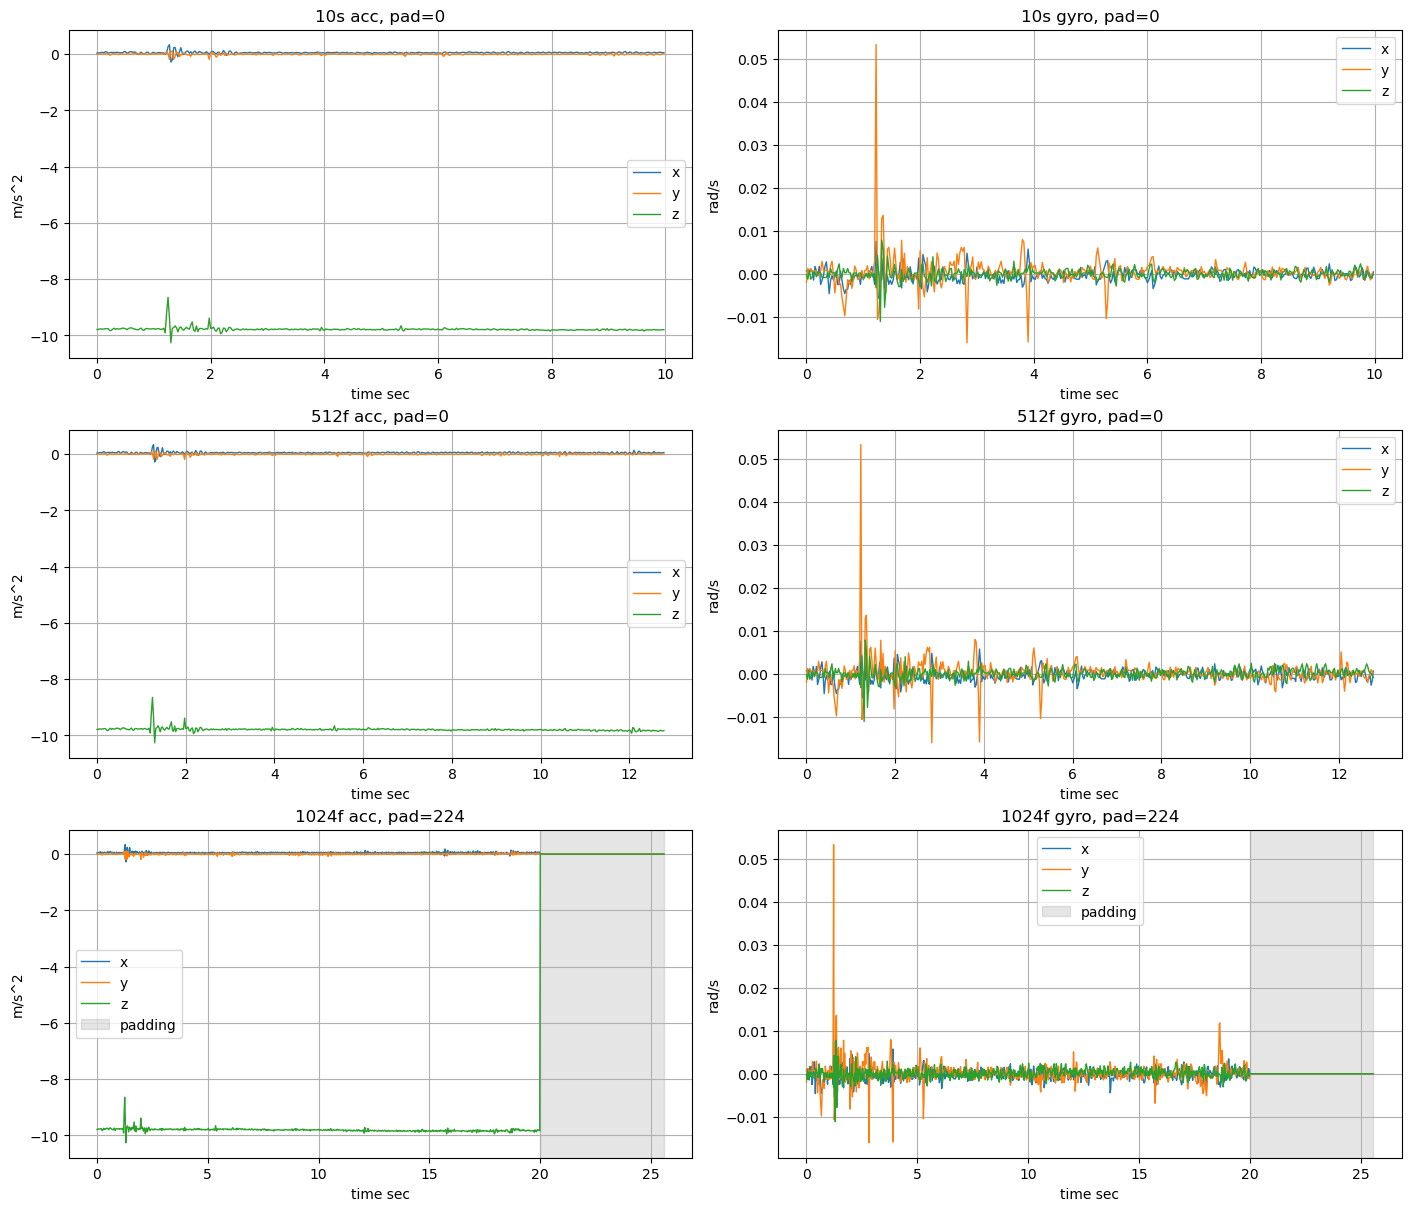

In [11]:
if sample_entries:
    fig, axes = plt.subplots(len(sample_entries), 2, figsize=(14, 4 * len(sample_entries)), constrained_layout=True)
    if len(sample_entries) == 1:
        axes = np.asarray([axes])

    for row, entry in enumerate(sample_entries):
        data = np.load(OUTPUT_ROOT / entry['dir'])
        acc = data['acc']
        gyro = data['gyro']
        t = acc[:, 0] / 1000.0
        pad_frames = entry['label']['pad_frames']
        real_end = len(t) - pad_frames

        for axis, label in enumerate(['x', 'y', 'z'], start=1):
            axes[row, 0].plot(t, acc[:, axis], linewidth=1.0, label=label)
        if pad_frames:
            axes[row, 0].axvspan(t[real_end], t[-1], color='gray', alpha=0.2, label='padding')
        axes[row, 0].set_title(f"{entry['mode']} acc, pad={pad_frames}")
        axes[row, 0].set_xlabel('time sec')
        axes[row, 0].set_ylabel('m/s^2')
        axes[row, 0].legend()

        for axis, label in enumerate(['x', 'y', 'z'], start=1):
            axes[row, 1].plot(t, gyro[:, axis], linewidth=1.0, label=label)
        if pad_frames:
            axes[row, 1].axvspan(t[real_end], t[-1], color='gray', alpha=0.2, label='padding')
        axes[row, 1].set_title(f"{entry['mode']} gyro, pad={pad_frames}")
        axes[row, 1].set_xlabel('time sec')
        axes[row, 1].set_ylabel('rad/s')
        axes[row, 1].legend()

    fig_path = OUTPUT_ROOT / 'figures' / 'sample_segments.svg'
    fig.savefig(fig_path)
    print('saved:', fig_path)
    plt.show()

## 9. Expected Full Script Behavior

如果这个 notebook 的结果符合预期，全量脚本可以按同一逻辑执行：

1. 遍历所有 acc/gyro 成对 `{uuid}/{timestamp}`。
2. 读取 4 列 `.dat` 文本。
3. 按文件判断 acc 单位，无法判断则跳过。
4. gyro 按 `rad/s` 处理。
5. 取 acc/gyro 时间交集。
6. 按 raw bin 阈值检查有效性。
7. 插值到 `40 Hz`。
8. 输出 `10s`、`512f`、`1024f` 三种模式。
9. `1024f` 尾部 padding 的数量写入 `label.pad_frames`。

本 notebook 不做全量写入，避免在确认前污染正式 processed 数据。